In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd


In [3]:
results_dir = Path("scratch") / "results" 
def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

stats_df = combine_dfs("bsbm_stats*.csv", results_dir)
timings_df = combine_dfs("bsbm_timings*.csv", results_dir)


In [4]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,2418,3,1,0.046760,0,Qlever (no Tensor Vocabulary),easy,embedded,1.0
1,2418,3,1,0.017234,1,Qlever (no Tensor Vocabulary),easy,embedded,1.0
2,2418,3,1,0.016769,2,Qlever (no Tensor Vocabulary),easy,embedded,1.0
3,2418,3,1,0.017745,3,Qlever (no Tensor Vocabulary),easy,embedded,1.0
4,2418,3,1,0.016982,4,Qlever (no Tensor Vocabulary),easy,embedded,1.0
...,...,...,...,...,...,...,...,...,...
315,42417,4,100,0.008135,11,Qlever (no Tensor Vocabulary),easy,index,1.0
316,42417,4,100,0.007636,12,Qlever (no Tensor Vocabulary),easy,index,1.0
317,42417,4,100,0.007706,13,Qlever (no Tensor Vocabulary),easy,index,1.0
318,42417,4,100,0.007430,14,Qlever (no Tensor Vocabulary),easy,index,1.0


In [5]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['Qlever (no Tensor Vocabulary)', 'FusekiDB + RDFTensor', 'Qlever']
Length: 3, dtype: str

In [6]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [7]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [8]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'Qlever (no Tensor Vocabulary)': 'C0',
 'FusekiDB + RDFTensor': 'C1',
 'Qlever': 'C2'}

/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


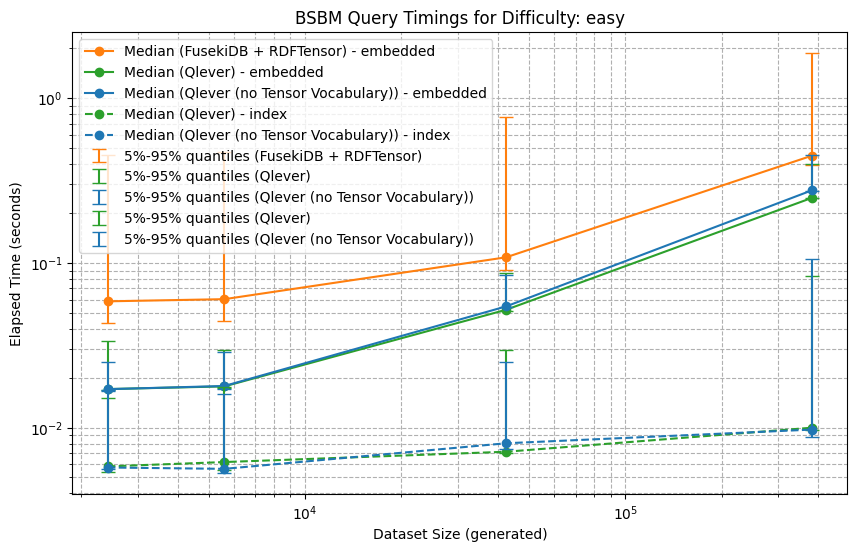

In [9]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, df, engine, difficulty, relevant_measure="elapsed_time"):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (generated)")
    ax.set_ylabel("Elapsed Time (seconds)")
    ax.set_title(f"BSBM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_timings.png")
plt.show()

In [10]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-16 11:50:52.807558,0.0,77254656,-1,1283136,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
1,2026-04-16 11:50:52.928303,49.7,78573568,-1,7031451,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
2,2026-04-16 11:50:53.049259,49.6,80670720,-1,11499573,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
3,2026-04-16 11:50:53.172127,57.0,80670720,-1,15996205,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
4,2026-04-16 11:50:53.297376,39.9,80670720,-1,20468499,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
...,...,...,...,...,...,...,...,...,...,...,...,...
352,2026-04-16 11:52:19.115627,53.9,77639680,-1,14847095,1,5595,3,easy,embedded,10,Qlever
353,2026-04-16 11:52:19.242377,47.4,77639680,-1,19527246,1,5595,3,easy,embedded,10,Qlever
354,2026-04-16 11:52:20.318235,0.0,75644928,-1,131301,1,5595,3,easy,index,10,Qlever
355,2026-04-16 11:52:20.433324,260.8,103038976,-1,1617117,1,5595,3,easy,index,10,Qlever


In [11]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


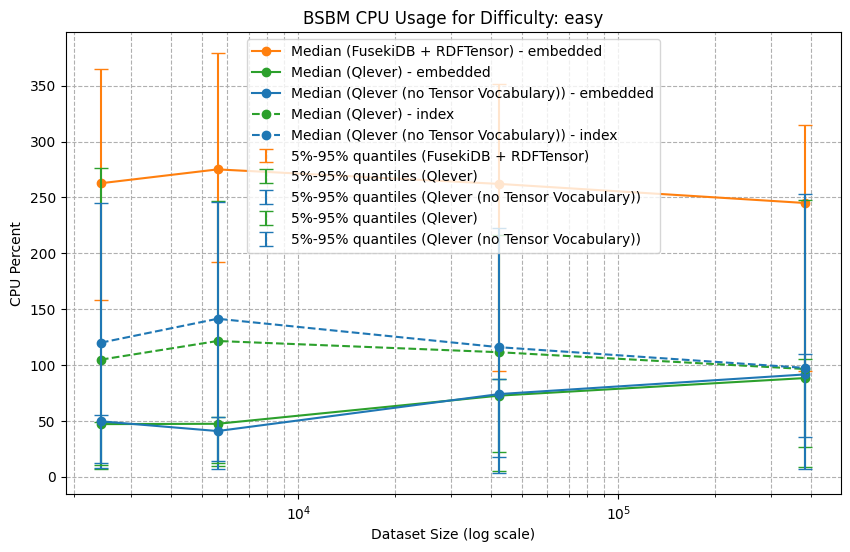

In [12]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="cpu_percent")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("CPU Percent")
    ax.set_title(f"BSBM CPU Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_cpu_usage.png")
plt.show()


/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


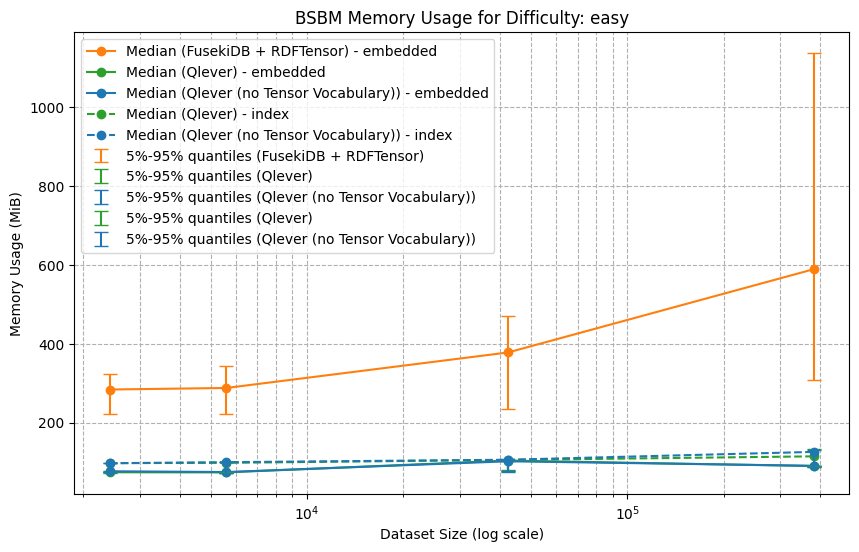

In [13]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="mem_usage_mb")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_title(f"BSBM Memory Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_mem_usage.png")
plt.show()
